# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](http://yann.lecun.com/exdb/mnist/) and include:

88% [Lecun et al., 1998](http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf)
95.3% [Lecun et al., 1998](http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf)
99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)

MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
torch.__version__, torchvision.__version__

('1.11.0+cu102', '0.10.0+cu102')

In [3]:
# Notebook throws error while loading dataset if this step is not done
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 139 kB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 214 kB 7.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.3 MB 24.4 MB/s eta 0:00:01
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [4]:
#Importing additional libraries
from tqdm import tqdm
from torchvision import transforms as T
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
import os
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd

In [5]:
# Define transforms

## YOUR CODE HERE ##
#train transforms 
train_transforms = T.Compose([
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])

#validation and test transforms
test_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])

# Create training set and define training dataloader
## YOUR CODE HERE ##
#We will first create a composite train dataset and then split it into train and validation dataset

dataset = datasets.MNIST(root="data", train=True, download=True)

tr_ds, v_ds = random_split(dataset, [50000, 10000], generator=torch.Generator().manual_seed(42))

#Custom dataset class so that we can apply appropriate transformation on the training and validation datasets
class MNIST_DS(Dataset):
    def __init__(self, ds, transform):
        super().__init__()
        self.ds = ds
        self.transform = transform
        self.len = len(self.ds)
        
    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, idx):
        img = self.ds[idx][0]
        img = self.transform(img)
        label = self.ds[idx][1]
        return img, label

#training dataset and dataloader
train_ds = MNIST_DS(tr_ds, train_transforms)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=os.cpu_count())

#validation dataset and dataloader
valid_ds = MNIST_DS(v_ds, test_transforms)
valid_dl = DataLoader(valid_ds, batch_size=32, shuffle=False, num_workers=os.cpu_count())

#test dataset and dataloader
test_ds = datasets.MNIST(root="data", train=False, download=True, transform=test_transforms)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

## YOUR CODE HERE ##

/opt/conda/lib/python3.7/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  ../torch/csrc/utils/tensor_numpy.cpp:178.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


In [6]:
len(train_ds), len(valid_ds), len(test_ds)

(50000, 10000, 10000)

In [7]:
train_ds[0][0].shape , train_ds[0][1], valid_ds[0][0].shape, valid_ds[0][1], test_ds[0][0].shape, test_ds[0][1], train_ds[0][0]

(torch.Size([1, 28, 28]),
 6,
 torch.Size([1, 28, 28]),
 4,
 torch.Size([1, 28, 28]),
 7,
 tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,  0.5451, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -0.4745,  0.8980,  0.9922,  1.0000,  0.5373, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000,

In [8]:
def check_data_balance(ds_name, ds):
    label_cnt_dict = {str(i):0 for i in range(10)}
    for tup in ds:
        label = tup[1]
        label_cnt_dict[str(label)] += 1
    print(f'Class Distribution of {ds_name} dataset is {label_cnt_dict}')
    return label_cnt_dict

In [9]:
train_count = check_data_balance("training", train_ds)
valid_count = check_data_balance("validation", valid_ds)
test_count = check_data_balance("test", test_ds)

Class Distribution of training dataset is {'0': 4923, '1': 5613, '2': 4958, '3': 5093, '4': 4863, '5': 4546, '6': 4933, '7': 5204, '8': 4882, '9': 4985}
Class Distribution of validation dataset is {'0': 1000, '1': 1129, '2': 1000, '3': 1038, '4': 979, '5': 875, '6': 985, '7': 1061, '8': 969, '9': 964}
Class Distribution of test dataset is {'0': 980, '1': 1135, '2': 1032, '3': 1010, '4': 982, '5': 892, '6': 958, '7': 1028, '8': 974, '9': 1009}


In [10]:
#With some deviations, the dataset more or less looks like a balanced one

In [11]:
import matplotlib.pyplot as plt

In [12]:
def draw_bar(ds_name, ds_dict):
    fig = plt.figure(figsize = (10, 5))
    labels = list(ds_dict.keys())
    counts = list(ds_dict.values())
    plt.bar(labels, counts, color='green', width=0.4)
    plt.xlabel("Class Labels")
    plt.ylabel("Class Label Count")
    plt.title(f'Class-wise distribution of {ds_name} dataset')
    plt.show()

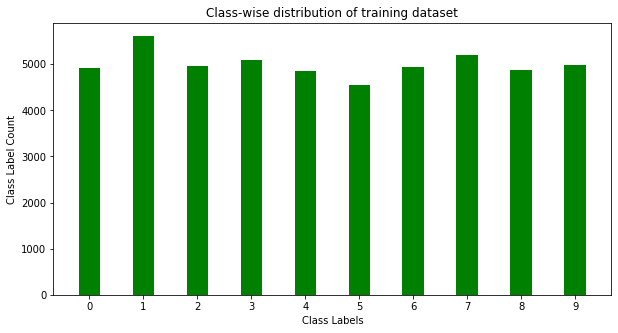

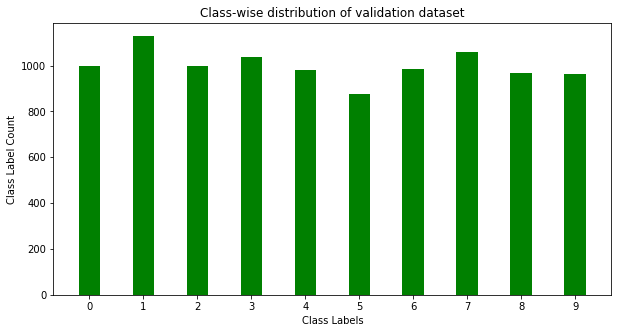

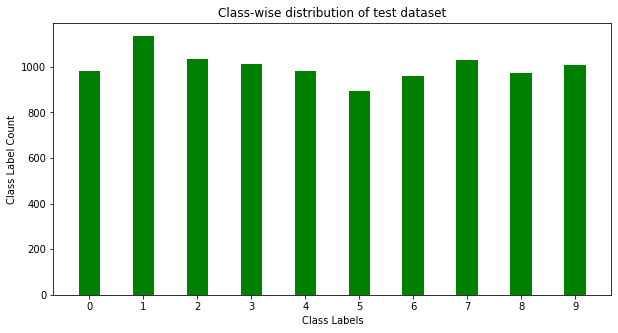

In [13]:
draw_bar("training", train_count)
draw_bar("validation", valid_count)
draw_bar("test", test_count)

## Justify your preprocessing

In your own words, why did you choose the transforms you chose? If you didn't use any preprocessing steps, why not?

I decided to perform random rotation on train dataset as it will add more variations in the images seen by the model hence, it will help in generalizing it better on test dataset. Further, I applied conversion into tensor(which converts it in range of 0 and 1 and further normalized it to center it between -1 and +1. These two are standard transforms and helps in faster training of neural networks.

**DOUBLE CLICK THIS CELL TO MODIFY**

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [14]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))
    
        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

Displaying 5 images from train dataset
3


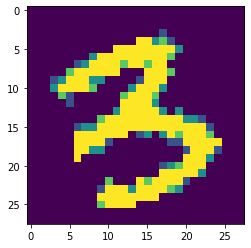

4


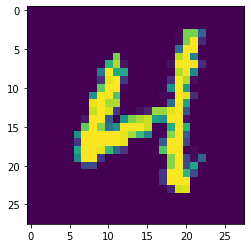

8


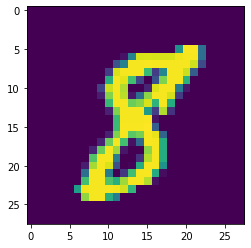

4


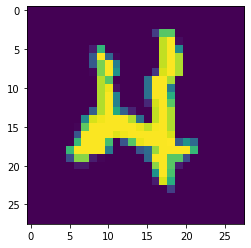

7


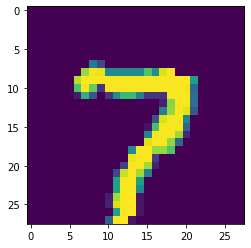

Displaying 5 images from validation dataset
4


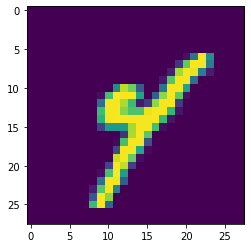

5


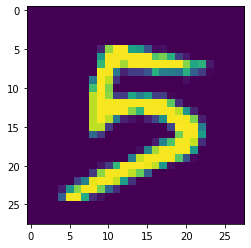

2


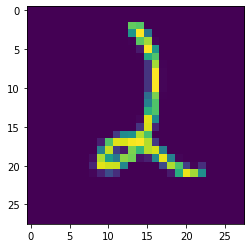

8


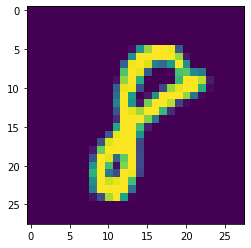

4


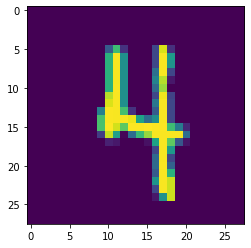

Displaying 5 images from test dataset
7


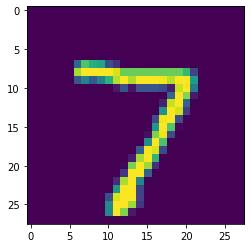

2


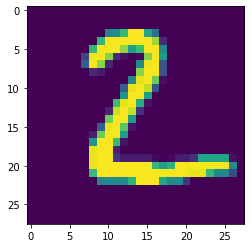

1


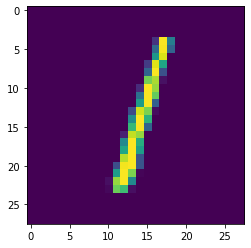

0


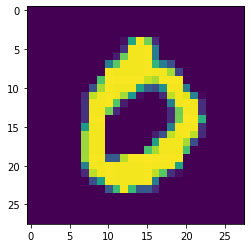

4


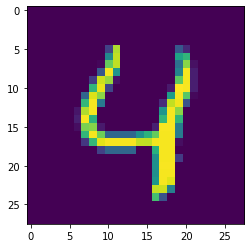

In [15]:
# Explore data
## YOUR CODE HERE ##
dl_list = [train_dl, valid_dl, test_dl]
dl_str = ["train", "validation", "test"]
for i, dl in enumerate(dl_list):
    print(f'Displaying 5 images from {dl_str[i]} dataset')
    show5(dl)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like. 

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [16]:
## YOUR CODE HERE ##
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.process_block = nn.Sequential(
            nn.Conv2d(1, 3, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(3,32, 3, padding=1, bias=False),
            nn.ReLU(inplace=True)
            )
        
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)
        )

        self.reduce_block = nn.Sequential(
            nn.Conv2d(64, 32, 7, bias=False),
            nn.ReLU(inplace=True),
        )
        
        self.classifier_block = nn.Sequential(
            nn.Conv2d(32, 10, 1),
            nn.Flatten(),
            nn.LogSoftmax(dim=1)
        )
        
        
    def forward(self, x):
        x = self.process_block(x)
        x = self.conv_block_1(x)
        x = self.reduce_block(x)
        x = self.classifier_block(x)
        return x
    
    def test_model(self, x):
        x = self(x)
        return x, x.shape

In [17]:
model = Net()
model

Net(
  (process_block): Sequential(
    (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU(inplace=True)
    (2): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): ReLU(inplace=True)
  )
  (conv_block_1): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (reduce_block): Sequential(
    (0): Conv2d(64, 32, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): ReLU(inplace=True)
  )
  (classifier_block): Sequential(
    (0): Conv2d(32, 10, kernel_size=(1, 1), stride=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): LogSoftmax(dim=1)
  )
)

In [18]:
x = torch.ones(3, 1, 28, 28)
print(x.shape)
out = model.test_model(x)
print(out)
num_param = sum([p.numel() for p in model.parameters()])
print(f'Number of Model Parameters : {num_param}')

torch.Size([3, 1, 28, 28])
(tensor([[-2.4578, -2.4253, -2.2439, -2.3563, -2.4220, -2.3997, -2.1615, -2.2738,
         -2.1245, -2.2251],
        [-2.4578, -2.4253, -2.2439, -2.3563, -2.4220, -2.3997, -2.1615, -2.2738,
         -2.1245, -2.2251],
        [-2.4578, -2.4253, -2.2439, -2.3563, -2.4220, -2.3997, -2.1615, -2.2738,
         -2.1245, -2.2251]], grad_fn=<LogSoftmaxBackward0>), torch.Size([3, 10]))
Number of Model Parameters : 156869


Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [19]:
## YOUR CODE HERE ##
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
model = model.to(device)
lr = 0.0002
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#We use NLLLoss here because we used LogSoftMax in our model's classifier block.
#Normally I dont use LogSoftMax in classifier block since it required to perform extra processing 
#steps when doing inference. I use nn.CrossEntropyLoss using Logits outputted by model.
# Cross Entropy Loss performs logsoftmax followed by NLLLoss internally so its quite logical that if 
# we use logsoftmax in classifier block, we have to use negative log loss likelihood as loss function
#to complete loss calculation. using softmax in classifer is project rubric requirement

cuda


## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [20]:
## YOUR CODE HERE ##
def train_validate_epochs(epochs, model):
    tr_loss = []
    tr_acc = []
    vl_loss = []
    vl_acc = []
    for i in range(epochs):
        model.train()
        accuracy_train = 0
        running_loss = 0
        
        for imgs, labels in train_dl:
            batch_size = imgs.shape[0]
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            loss_train = criterion(output, labels)
            optimizer.zero_grad()
            loss_train.backward()
            optimizer.step()
            running_loss += loss_train.item()*batch_size
        
            ps = torch.exp(output)
            top_p, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            accuracy_train += torch.sum(equals.type(torch.FloatTensor)).item()
        
        model.eval()
        accuracy_valid = 0
        loss_valid = 0
        with torch.no_grad():
            for imgs_valid, labels_valid in valid_dl:
                batch_size_valid = imgs_valid.shape[0]
                imgs_valid, labels_valid = imgs_valid.to(device), labels_valid.to(device)
                output_valid = model(imgs_valid)
                loss = criterion(output_valid, labels_valid)
                loss_valid += loss.item()*batch_size_valid
            
                ps = torch.exp(output_valid)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels_valid.view(*top_class.shape)
                accuracy_valid += torch.sum(equals.type(torch.FloatTensor)).item()
        
        avg_tr_loss = round(running_loss/len(train_ds), 5)
        avg_vl_loss = round(loss_valid/len(valid_ds), 5)
        avg_tr_acc = round(accuracy_train/len(train_ds),5)
        avg_vl_acc = round(accuracy_valid/len(valid_ds), 5)
        tr_loss.append(avg_tr_loss)
        vl_loss.append(avg_vl_loss)
        tr_acc.append(avg_tr_acc)
        vl_acc.append(avg_vl_acc)
        print(f'Epoch {i+1}/{epochs}:\
        \nTraining DS: Loss: {avg_tr_loss}; Accuracy: {avg_tr_acc}\
        \nValid DS:    Loss: {avg_vl_loss}; Accuracy: {avg_vl_acc}')
    return model, tr_loss, vl_loss, tr_acc, vl_acc

In [21]:
epochs = 7
model, tr_loss, vl_loss, tr_acc, vl_acc =  train_validate_epochs(epochs, model)

Epoch 1/7:        
Training DS: Loss: 0.44591; Accuracy: 0.8562        
Valid DS:    Loss: 0.15887; Accuracy: 0.9522
Epoch 2/7:        
Training DS: Loss: 0.15589; Accuracy: 0.95092        
Valid DS:    Loss: 0.09678; Accuracy: 0.9711
Epoch 3/7:        
Training DS: Loss: 0.1142; Accuracy: 0.96438        
Valid DS:    Loss: 0.08025; Accuracy: 0.9741
Epoch 4/7:        
Training DS: Loss: 0.09145; Accuracy: 0.9707        
Valid DS:    Loss: 0.06719; Accuracy: 0.9794
Epoch 5/7:        
Training DS: Loss: 0.07779; Accuracy: 0.97622        
Valid DS:    Loss: 0.05325; Accuracy: 0.9839
Epoch 6/7:        
Training DS: Loss: 0.06726; Accuracy: 0.97914        
Valid DS:    Loss: 0.0586; Accuracy: 0.9822
Epoch 7/7:        
Training DS: Loss: 0.06084; Accuracy: 0.9816        
Valid DS:    Loss: 0.04403; Accuracy: 0.9865


In [22]:
len(tr_loss), len(vl_loss), len(tr_acc), len(vl_acc)

(7, 7, 7, 7)

Plot the training loss (and validation loss/accuracy, if recorded).

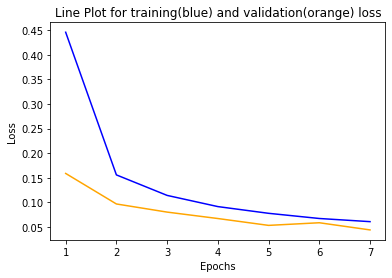

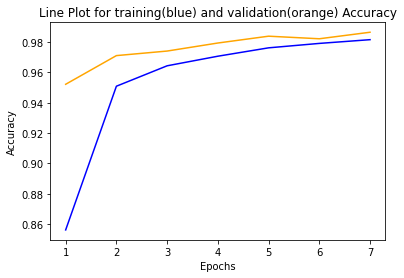

In [26]:
## YOUR CODE HERE ##
epochs = [i for i in range(1, 8)]
plt.plot(epochs, tr_loss, color='blue')
plt.plot(epochs, vl_loss, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f'Line Plot for training(blue) and validation(orange) loss')
plt.show()

plt.plot(epochs, tr_acc, color='blue')
plt.plot(epochs, vl_acc, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f'Line Plot for training(blue) and validation(orange) Accuracy')
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 90%, great work, but see if you can push a bit further! 
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [27]:
## YOUR CODE HERE ##
def test_model(model):
    model.eval()
    accuracy_test = 0
    loss_test = 0
    with torch.no_grad():
        for imgs_test, labels_test in test_dl:
            batch_size_test = imgs_test.shape[0]
            imgs_test, labels_test = imgs_test.to(device), labels_test.to(device)
            output_test = model(imgs_test)
            loss = criterion(output_test, labels_test)
            loss_test += loss.item()*batch_size_test
            
            ps = torch.exp(output_test)
            top_p, top_class = ps.topk(1, dim=1)
            equals = top_class == labels_test.view(*top_class.shape)
            accuracy_test += torch.sum(equals.type(torch.FloatTensor)).item()
        
    print(f'Test DS:    Loss: {round(loss_test/len(test_ds), 5)}; Accuracy: {round(accuracy_test/len(test_ds), 5)}')

In [28]:
test_model(model)

Test DS:    Loss: 0.03723; Accuracy: 0.9885


## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [29]:
## YOUR CODE HERE ## We add BatchNorm and Dropout plus we train at higher learning rate 0.0005
class Net_Improved(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.process_block = nn.Sequential(
            nn.Conv2d(1, 3, 3, padding=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True),
            nn.Conv2d(3,32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.02)
        )
        
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.02),
            nn.MaxPool2d(2,2)
        )
        
        
        self.reduce_block = nn.Sequential(
            nn.Conv2d(64, 32, 7),
            nn.ReLU(inplace=True)
        )
        
        self.classifier_block = nn.Sequential(
            nn.Conv2d(32, 10, 1),
            nn.Flatten(),
            nn.LogSoftmax(dim=1)
        )
        
        
    def forward(self, x):
        x = self.process_block(x)
        x = self.conv_block_1(x)
        x = self.reduce_block(x)
        x = self.classifier_block(x)
        return x
    
    def test_model(self, x):
        x = self(x)
        return x, x.shape

In [30]:
model_improved = Net_Improved()
model_improved

Net_Improved(
  (process_block): Sequential(
    (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Dropout2d(p=0.02, inplace=False)
  )
  (conv_block_1): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Re

In [31]:
x = torch.ones(3, 1, 28, 28)
print(x.shape)
out = model_improved.test_model(x)
print(out)
num_param = sum([p.numel() for p in model_improved.parameters()])
print(f'Number of Model Parameters : {num_param}')

torch.Size([3, 1, 28, 28])
(tensor([[-2.1469, -2.4286, -2.1330, -2.7658, -2.5090, -1.9509, -2.4889, -2.4999,
         -2.0978, -2.2800],
        [-2.1586, -2.3585, -2.1903, -2.7163, -2.5312, -1.9608, -2.5043, -2.5442,
         -2.0398, -2.2894],
        [-2.0228, -2.5672, -2.0821, -2.6599, -2.3957, -1.9603, -2.6312, -2.6483,
         -2.1659, -2.2349]], grad_fn=<LogSoftmaxBackward0>), torch.Size([3, 10]))
Number of Model Parameters : 157227


In [32]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
model_improved = model_improved.to(device)
lr = 0.0005
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(model_improved.parameters(), lr=lr)

cuda


In [33]:
epochs = 15
model_improved, tr_loss_im, vl_loss_im, tr_acc_im, vl_acc_im =  train_validate_epochs(epochs, model_improved)

Epoch 1/15:        
Training DS: Loss: 0.16899; Accuracy: 0.94878        
Valid DS:    Loss: 0.07562; Accuracy: 0.9755
Epoch 2/15:        
Training DS: Loss: 0.07345; Accuracy: 0.97708        
Valid DS:    Loss: 0.04857; Accuracy: 0.9859
Epoch 3/15:        
Training DS: Loss: 0.06019; Accuracy: 0.9811        
Valid DS:    Loss: 0.04369; Accuracy: 0.9871
Epoch 4/15:        
Training DS: Loss: 0.05267; Accuracy: 0.98396        
Valid DS:    Loss: 0.03202; Accuracy: 0.9898
Epoch 5/15:        
Training DS: Loss: 0.04601; Accuracy: 0.9853        
Valid DS:    Loss: 0.0326; Accuracy: 0.9885
Epoch 6/15:        
Training DS: Loss: 0.04282; Accuracy: 0.98682        
Valid DS:    Loss: 0.04024; Accuracy: 0.9878
Epoch 7/15:        
Training DS: Loss: 0.03794; Accuracy: 0.98784        
Valid DS:    Loss: 0.02791; Accuracy: 0.9911
Epoch 8/15:        
Training DS: Loss: 0.03483; Accuracy: 0.98874        
Valid DS:    Loss: 0.03628; Accuracy: 0.9901
Epoch 9/15:        
Training DS: Loss: 0.03017; Acc

In [34]:
test_model(model_improved)

Test DS:    Loss: 0.01692; Accuracy: 0.9943


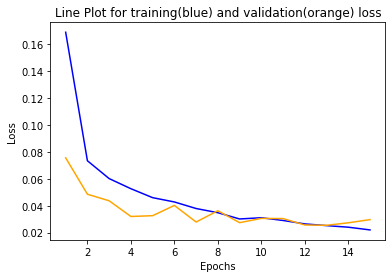

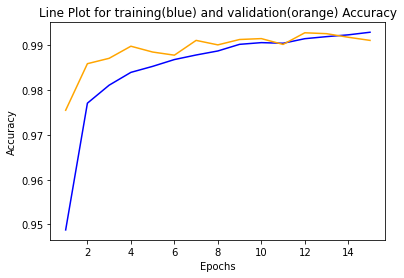

In [35]:
## YOUR CODE HERE ##
epochs = [i for i in range(1, 16)]
plt.plot(epochs, tr_loss_im, color='blue')
plt.plot(epochs, vl_loss_im, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f'Line Plot for training(blue) and validation(orange) loss')
plt.show()

plt.plot(epochs, tr_acc_im, color='blue')
plt.plot(epochs, vl_acc_im, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f'Line Plot for training(blue) and validation(orange) Accuracy')
plt.show()

## Saving your model
Using `torch.save`, save your model for future loading.

In [36]:
## YOUR CODE HERE ##
torch.save(model_improved.state_dict(), "MNIST_99.43_TEST_ACC_checkpoint.pth")